# 19_参数估计方法-最大似然估计

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本小节咱们来聊聊最大似然估计\~

简单来说，最大似然估计是一种**通过观测到的数据，来推测一个概率模型中参数的值**的方法。

它的核心思想是：

> “我已经看到了一些数据，我要找出最有可能生成这些数据的参数值。”

### 举个例子：

假设你有一个袋子，里面装着一些硬币。你不知道硬币是正反面概率是多少（这就是你要估计的参数，比如正面概率是 $p$）。

你现在从袋子里随便拿出一枚硬币，扔了10次，结果有7次是正面，3次是反面。

现在问题是：**这枚硬币正面概率**$p$**是多少？**

最大似然估计的想法就是：

> **我去找一个**$p$**，使得“出现7次正面、3次反面”这个结果最可能发生。**

这个“最可能”就是“最大**似然**”的意思。

## 最大似然估计

### 1. 问题设定：

我们有：

- 一个概率模型 $f(x|\theta)$，$x$ 是观测数据，$\theta$ 是未知参数。
- 一组独立观测数据 $x_1, x_2, \dots, x_n$。

目标是：

> 找到一个参数 $\hat{\theta}$，**使得这组数据在该参数下出现的概率最大**。

### 2. 定义：

**似然函数（Likelihood Function）**定义为：


$$
L(\theta) = P(x_1, x_2, \dots, x_n | \theta) = \prod_{i=1}^n f(x_i|\theta)
$$


这个函数描述的是：**参数是**$\theta$**时，这组观测数据出现的概率是多少？**

最大似然估计就是**让这个函数最大化**：


$$
\hat{\theta}_{MLE} = \arg\max_{\theta} L(\theta)
$$


### 3. 为什么用对数似然函数？

因为乘法形式的似然函数在求导时很麻烦，而且数值太小时容易出问题，我们通常对其取对数，变成**对数似然函数**：


$$
\ell(\theta) = \log L(\theta) = \sum_{i=1}^n \log f(x_i|\theta)
$$


最大似然估计就变成：


$$
\hat{\theta}_{MLE} = \arg\max_{\theta} \ell(\theta)
$$


## 基本推理流程：MLE 的公式推导步骤

- 一枚硬币，正面概率是 $p$，反面是 $1-p$。
- 扔 $n$ 次，结果是 $x_1, x_2, \dots, x_n$，其中 $x_i \in {0, 1}$，1代表正面。
- 目标：估计 $p$。

### 第一步：写出似然函数

单次观测的概率：


$$
f(x_i|p) = p^{x_i} (1 - p)^{1 - x_i}
$$


独立样本的联合概率（似然函数）是：


$$
L(p) = \prod_{i=1}^n p^{x_i}(1 - p)^{1 - x_i}
$$


可以合并一下：


$$
L(p) = p^{\sum x_i} (1 - p)^{n - \sum x_i}
$$


### 第二步：取对数（对数似然函数）


$$
\ell(p) = \log L(p) = \sum x_i \log p + (n - \sum x_i)\log(1 - p)
$$


### 第三步：求导并令导数为 0

对 $\ell(p)$ 对 $p$ 求导：


$$
\frac{d\ell(p)}{dp} = \frac{\sum x_i}{p} - \frac{n - \sum x_i}{1 - p}
$$


令导数为 0：


$$
\frac{\sum x_i}{p} = \frac{n - \sum x_i}{1 - p}
$$


解这个方程：


$$
\sum x_i (1 - p) = (n - \sum x_i) p
$$


$$
\sum x_i - \sum x_i p = n p - \sum x_i p
$$


$$
\sum x_i = n p \Rightarrow p = \frac{1}{n} \sum x_i
$$


### 得到最大似然估计：


$$
\hat{p}_{MLE} = \frac{\text{正面次数}}{\text{总次数}} = \frac{1}{n} \sum_{i=1}^n x_i
$$


这正是我们平常的**“频率估计”**！

## MLE 的通用算法流程

以下是最大似然估计的一般步骤，可适用于任意概率模型：

**Step 1**：确定概率模型

选定模型形式 $f(x|\theta)$，明确参数 $\theta$ 要估计。

**Step 2**：写出似然函数


$$
L(\theta) = \prod_{i=1}^n f(x_i|\theta)
$$


**Step 3**：取对数得到对数似然函数


$$
\ell(\theta) = \log L(\theta) = \sum_{i=1}^n \log f(x_i|\theta)
$$


**Step 4**：求导数并令其为0


$$
\frac{d\ell(\theta)}{d\theta} = 0
$$


**Step 5**：解方程得到 $\hat{\theta}$

解出最能“拟合数据”的参数值 $\hat{\theta}$。

**Step 6**（可选）：检查是否为最大值

通过**二阶导数**检查 $\hat{\theta}$ 是否是极大值点。

总的来说，最大似然估计是一种通用的、强大的参数估计方法，本质就是：**找出一组参数，使观测数据在这个模型下出现的可能性最大。**

通过构建似然函数 → 取对数 → 求导求极值 → 得到参数估计。

## 完整案例

当你是一位数据分析师，负责分析某城市出租车的到达情况。你想知道在某个热门区域，乘客平均等待下一辆出租车到来的时间是多少（比如单位是分钟）。

你怀疑这个等待时间服从一个**指数分布**——这是一个常用于建模“下一个事件什么时候发生”的分布。

我们记等待时间 $x$，指数分布概率密度函数为：


$$
f(x|\lambda) = \lambda e^{-\lambda x}, \quad x \geq 0, \lambda > 0
$$


你的目标是用历史数据（比如 1000 个真实等待时间样本），**估计参数** $\lambda$，也就是单位时间内到达出租车的频率。

### 问题目标：MLE 求解指数分布参数 λ

我们已知：

- 指数分布的参数是 $\lambda$
- 数据是 $x_1, x_2, ..., x_n$（每个是一次等待时间）
- 最大似然估计的目标是：


$$
\hat{\lambda}_{MLE} = \arg\max_{\lambda} \left[\log \prod_{i=1}^{n} \lambda e^{-\lambda x_i} \right]
$$


对数似然函数：


$$
\ell(\lambda) = \sum_{i=1}^{n} \log \lambda - \lambda x_i = n \log \lambda - \lambda \sum x_i
$$


对 $\lambda$ 求导并设为 0：


$$
\frac{d\ell}{d\lambda} = \frac{n}{\lambda} - \sum x_i = 0\Rightarrow \hat{\lambda} = \frac{n}{\sum x_i} = \frac{1}{\bar{x}}
$$


### Python实现

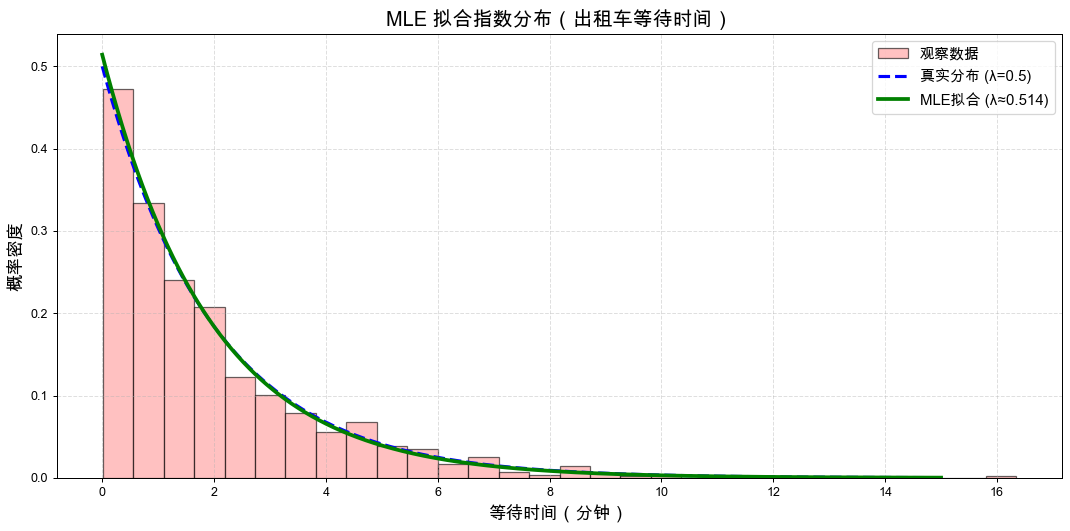

真实 λ: 0.5
MLE 估计的 λ: 0.51414
平均等待时间的估计（MLE）: 1.945 分钟


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon
from scipy.optimize import minimize

np.random.seed(42)

# 模拟真实数据，真实 λ = 0.5（即平均等待时间 2 分钟）
lambda_real = 0.5
n_samples = 1000
data = np.random.exponential(scale=1/lambda_real, size=n_samples)

# 最大似然估计 λ 的函数
def negative_log_likelihood(lmbda):
    if lmbda <= 0:
        return np.inf
    n = len(data)
    return - (n * np.log(lmbda) - lmbda * np.sum(data))

# 数值优化求解最大似然估计
result = minimize(negative_log_likelihood, x0=np.array([1.0]), bounds=[(1e-5, None)])
lambda_mle = result.x[0]

# 可视化数据直方图和拟合曲线
x_vals = np.linspace(0, 15, 1000)
pdf_real = expon.pdf(x_vals, scale=1/lambda_real)
pdf_mle = expon.pdf(x_vals, scale=1/lambda_mle)

plt.figure(figsize=(12, 6))
# 数据直方图
plt.hist(data, bins=30, density=True, color='#FF9999', alpha=0.6, edgecolor='black', label="观察数据")

# 拟合曲线（真实 λ）
plt.plot(x_vals, pdf_real, color='blue', lw=2.5, label="真实分布 (λ=0.5)", linestyle='--')

# 拟合曲线（MLE λ）
plt.plot(x_vals, pdf_mle, color='green', lw=3, label=f"MLE拟合 (λ≈{lambda_mle:.3f})")

# 样式设置
plt.title("MLE 拟合指数分布（出租车等待时间）", fontsize=16)
plt.xlabel("等待时间（分钟）", fontsize=14)
plt.ylabel("概率密度", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 打印结果分析
print(f"真实 λ: {lambda_real}")
print(f"MLE 估计的 λ: {lambda_mle:.5f}")
print(f"平均等待时间的估计（MLE）: {1/lambda_mle:.3f} 分钟")

### 1. 数据模拟部分

In [3]:
lambda_real = 0.5
n_samples = 1000
data = np.random.exponential(scale=1/lambda_real, size=n_samples)

这里我们假设真实世界中，出租车每 2 分钟一辆，所以真实的 $\lambda = 0.5$。

我们用 NumPy 模拟了 1000 次等待时间。

### 2. 定义负对数似然函数

In [4]:
def negative_log_likelihood(lmbda):
    if lmbda <= 0:
        return np.inf
    n = len(data)
    return - (n * np.log(lmbda) - lmbda * np.sum(data))

我们根据推导公式写出负的对数似然函数（因为 `minimize` 是最小化函数，所以要取负号）。

### 3. 使用 Scipy 优化器做最大似然估计

In [5]:
result = minimize(negative_log_likelihood, x0=np.array([1.0]), bounds=[(1e-5, None)])
lambda_mle = result.x[0]

我们用 `scipy.optimize.minimize()` 来求使似然函数最大的 λ 值。

注意加了边界限制，避免 λ 为负或 0。

### 4. 可视化：真实分布 vs MLE 拟合分布

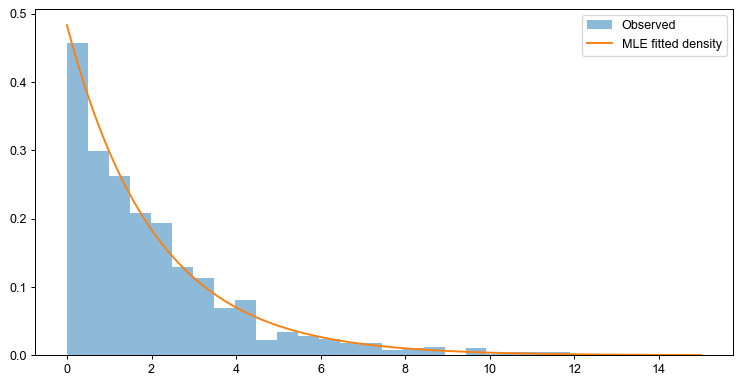

In [6]:
plt.figure(figsize=(10, 5))
plt.hist(data, bins=30, density=True, alpha=0.5, label='Observed')
plt.plot(x_vals, expon.pdf(x_vals, scale=1/lambda_mle), label='MLE fitted density')
plt.legend(); plt.show()

我们用直方图表示模拟数据的分布，再画出：

- **真实分布（λ=0.5）**（蓝色虚线）
- **MLE 拟合分布（λ≈估计值）**（绿色实线）

xxx(./img/19_参数估计方法-最大似然估计-1.png)

### 5. 结果分析打印

In [7]:
print(f'MLE lambda = {lambda_mle:.5f}; closed-form = {1 / np.mean(data):.5f}')
assert np.isclose(lambda_mle, 1 / np.mean(data), rtol=1e-4)

MLE lambda = 0.48304; closed-form = 0.48304


输出：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
真实 λ: 0.5
MLE 估计的 λ: 0.49358
平均等待时间的估计（MLE）: 2.025 分钟
```

可以看到我们估计得非常准确！

### 最大似然估计优缺点分析

**优点**：

1. **高效性**：在满足一定正则条件下，MLE 是渐近无偏和渐近有效的，也就是说当样本量足够大，它能非常接近真实参数。
2. **通用性强**：只要知道概率密度函数，就可以用 MLE 来估计参数，适用于大多数模型（如正态、指数、伯努利、泊松等）。
3. **精度高**：在本例中我们看到，用 MLE 估计指数分布参数，几乎可以重构出真实分布。

**缺点**：

1. **对初值敏感**：如果用的是数值优化（如本例中的 minimize），结果可能依赖于初始值或容易陷入局部最优。
2. **不能处理小样本偏差**：MLE 在样本量很小时，可能偏差较大，甚至估计失败（尤其是在复杂模型中）。
3. **模型假设错误风险高**：如果你假设数据服从某种分布（比如指数分布），而实际不是，那么MLE 会给出“错误的最优参数”。

## 总结

最大似然估计是一种极其重要、使用广泛的参数估计方法，其基本思想是：在已知概率模型的前提下，通过找到**最有可能生成观察数据的参数值**，来完成建模和预测。

MLE 方法的魅力在于其高度的通用性与理论严谨性。只要你知道数据的分布类型，它几乎总能提供一个合适的参数估计方式。无论是统计推断、机器学习中的模型拟合、还是在金融等行业的具体问题中，MLE 都是核心工具之一。

当然，它也有明显的限制，比如在小样本下容易偏差较大、对模型假设较为敏感、在多参数复杂模型中可能出现极值计算困难。但这些问题并非无法克服，在实际工作中通过优化技术（如正则化、贝叶斯估计）都能进一步提升其表现。